**What is an Explanation?**
An explanation is a humna-understandable description of why a model produced a specific prediciton or how it behaves.

**Local vs Global Explanations**
- Local: Explains one specific prediction.
- Global: Explain the overall behaviour of the model across the entire dataset  

**Model-specific vs Model-agnostic Explanations**
- Model-specific: Exploits the model structure.
- Model-agnostic: Treat the model as black box and only uses inputs and outputs of the model to generate explanations.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

In [ ]:
model = XGBClassifier(
  n_estimators=100,
  max_depth=3,
  learning_rate=0.01,
  random_state=42
)

In [ ]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

In [ ]:
g_logistic = LogisticRegression(
    max_iter=1000,
)

g_logistic.fit(X_train, y_hat_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
g_tree = DecisionTreeClassifier(
    max_depth=3,
    criterion="gini",
    random_state=42
)

g_tree.fit(X_train, y_hat_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
logistic_fidelity = accuracy_score(
    y_hat_test,
    g_logistic.predict(X_test)
)

print("Logistic surrogate fidelity:", logistic_fidelity)

Logistic surrogate fidelity: 0.9736842105263158


In [ ]:
tree_fidelity = accuracy_score(
    y_hat_test,
    g_tree.predict(X_test)
)

print("Tree surrogate fidelity:", tree_fidelity)

Tree surrogate fidelity: 0.9824561403508771


## Global Explanations

In [ ]:
coeffs = g_logistic.coef_[0]

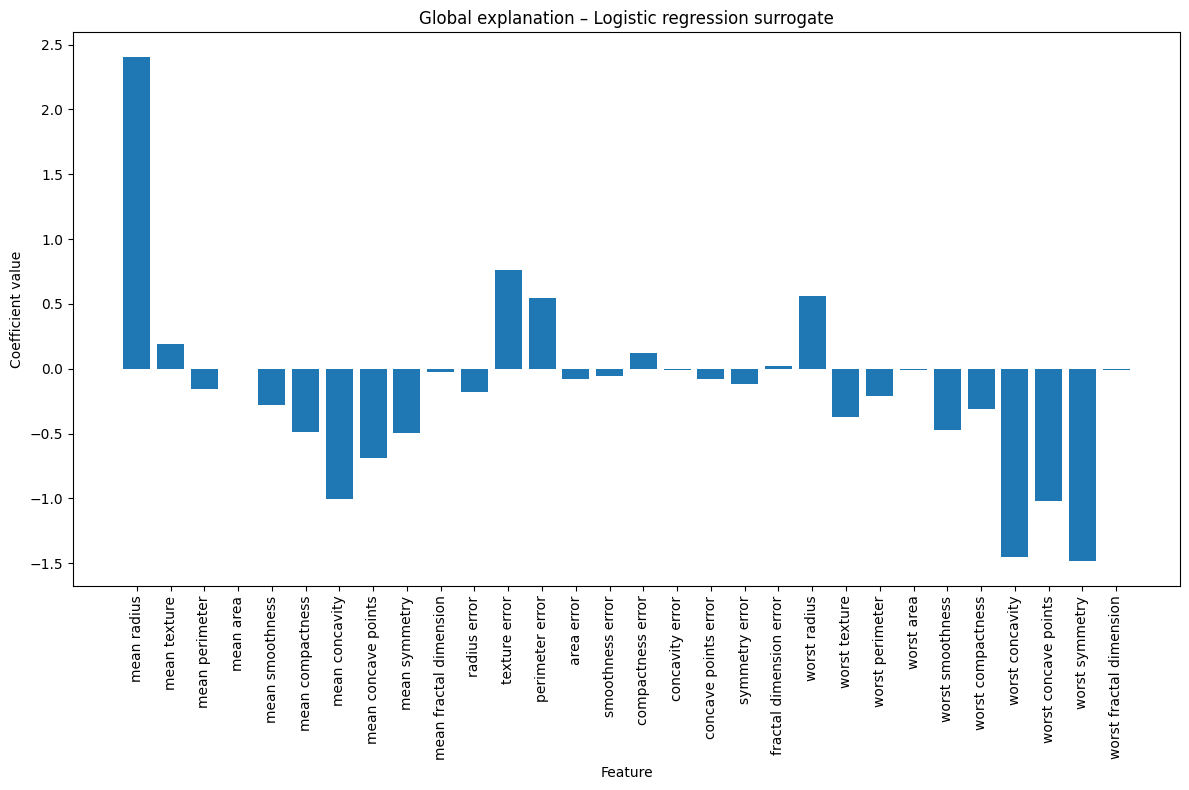

In [ ]:
plt.figure(figsize=(12,8))
plt.bar(feature_names, coeffs)
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Coefficient value")
plt.title("Global explanation – Logistic regression surrogate")
plt.tight_layout()
plt.show()

- A **positive coefficient** indicates that increasing the feature value increases the predicted probability of the positive class
- A **negative coefficient** indicates that increasing the feature value decreases the predicted probability of the positive class.
- The **magnitude** of the coefficient indicates how strongly the feature affects the model's prediction if all other features are constant.
- The features related to tumor size suh as mean radius and worst radius have coefficients with large magnitudes, this indicates that the moedl relies strongly on these features to make predictions.

In [ ]:
importances = g_tree.feature_importances_

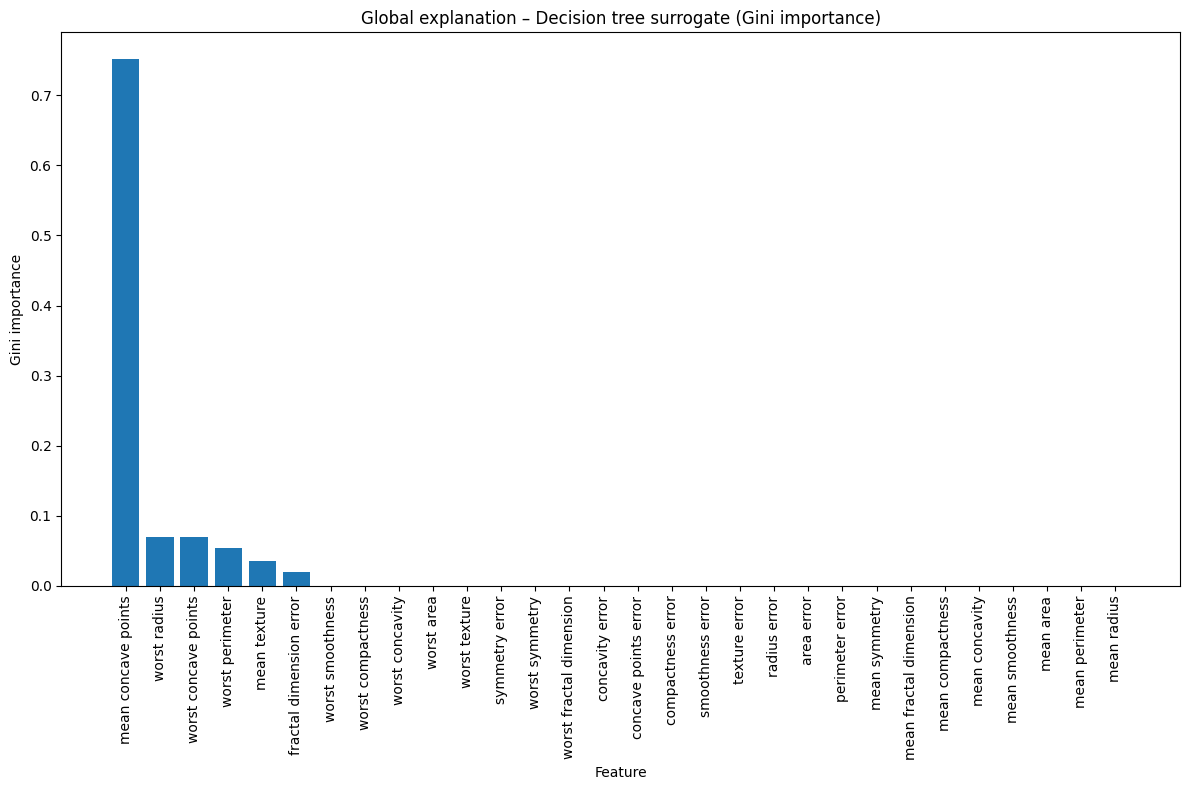

In [ ]:
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(12,8))
plt.bar(np.array(feature_names)[idx], importances[idx])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Gini importance")
plt.title("Global explanation – Decision tree surrogate (Gini importance)")
plt.tight_layout()
plt.show()

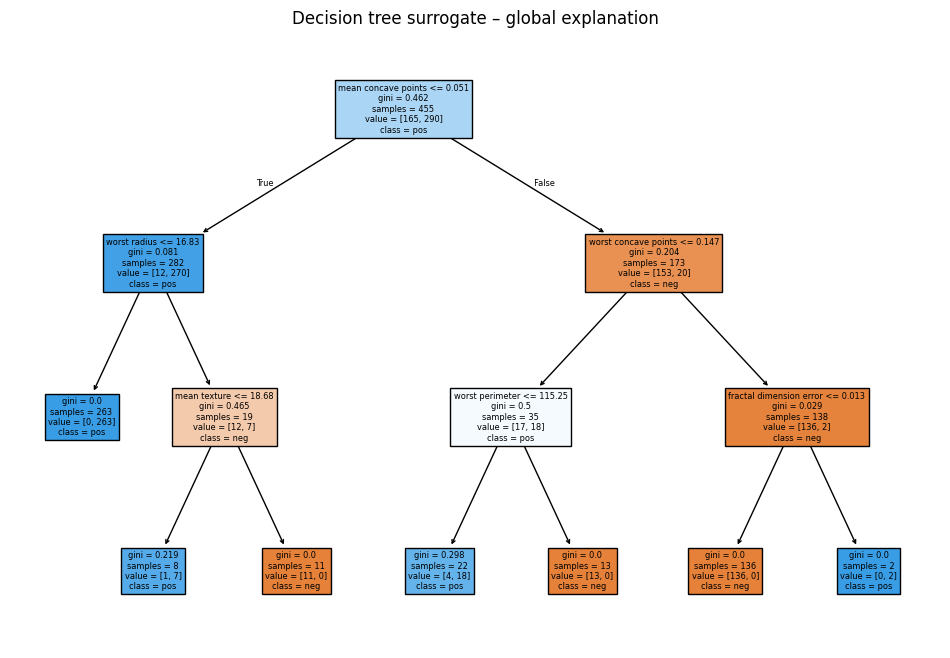

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(
    g_tree,
    feature_names=feature_names,
    class_names=["neg", "pos"],
    filled=True,
    max_depth=3
)
plt.title("Decision tree surrogate – global explanation")
plt.show()


- The surrogate tree model relies havily on the **mean concave points** feature to approximate the model's prediciton.
- If **mean concave points** is less than $0.051$, the model mostly predict positive, otherwise, it mostly predicts negative.

## Local Explanation

In [ ]:
x0 = X_test[0].reshape(1, -1)

In [ ]:
f_prob = model.predict_proba(x0)[0, 1]
f_pred = int(f_prob >= 0.5)

print("Black-box probability:", f_prob)
print("Black-box predicted class:", f_pred)

Black-box probability: 0.8546731
Black-box predicted class: 1


In [ ]:
coeffs = g_logistic.coef_[0]
local_contributions = coeffs * x0.flatten()

In [ ]:
for name, val in sorted(
    zip(feature_names, local_contributions),
    key=lambda x: abs(x[1]),
    reverse=True
):
    print(f"{name}: {val:.4f}")

mean radius: 29.9375
worst perimeter: -19.9076
mean perimeter: -12.3281
worst texture: -9.1130
worst radius: 8.3833
worst area: -6.5915
mean texture: 3.5681
mean area: -2.5606
area error: -2.3902
perimeter error: 1.3691
texture error: 0.7946
worst symmetry: -0.4460
worst concavity: -0.3873
worst concave points: -0.1034
mean symmetry: -0.0950
mean concavity: -0.0803
worst compactness: -0.0733
radius error: -0.0698
worst smoothness: -0.0678
mean compactness: -0.0519
mean smoothness: -0.0278
mean concave points: -0.0262
compactness error: 0.0023
symmetry error: -0.0021
mean fractal dimension: -0.0018
concave points error: -0.0008
worst fractal dimension: -0.0006
smoothness error: -0.0004
concavity error: -0.0002
fractal dimension error: 0.0001


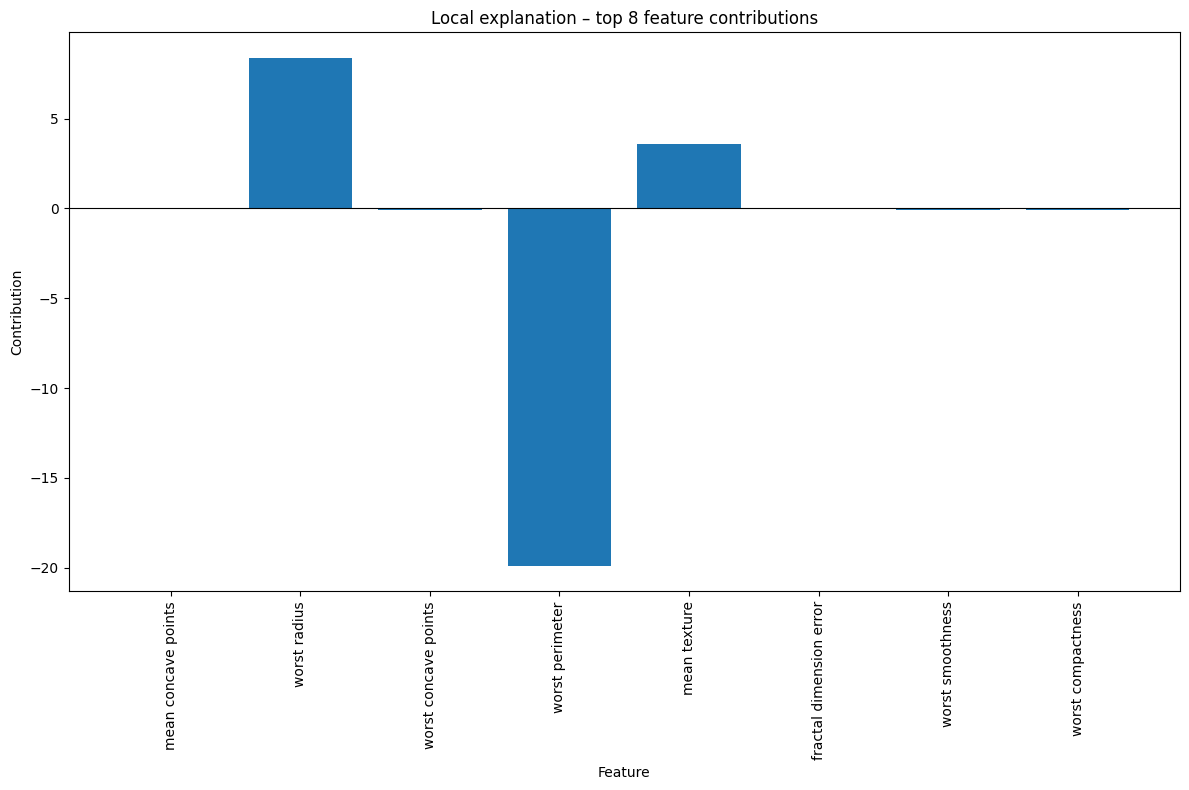

In [ ]:
k = 8

top_idx = idx[:k]

plt.figure(figsize=(12, 8))
plt.bar(
    np.array(feature_names)[top_idx],
    local_contributions[top_idx]
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Contribution")
plt.title(f"Local explanation – top {k} feature contributions")
plt.tight_layout()
plt.show()

In [ ]:
node_indicator = g_tree.decision_path(x0)
leaf_id = g_tree.apply(x0)

print("Decision path node indices:", node_indicator.indices)
print("Leaf node:", leaf_id)

Decision path node indices: [0 1 2]
Leaf node: [2]
